In [1]:
# ==== Core Libraries ====
import os
import copy
import random
from collections import Counter
from datetime import datetime

# ==== Data Processing ====
import numpy as np
import pandas as pd
from scipy import stats

# ==== PyTorch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler

# ==== Machine Learning Utils ====
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# ==== Visualization ====
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Discriminator(nn.Module):
    def __init__(self, input_channel, features_d, num_classes, num_aps, input_width):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.num_aps = num_aps
        self.input_width = input_width
        self.input_channel = input_channel

        if self.num_aps == 11:
            last_kernal_size = 12
            last_stride = 5
            last_padding = 4

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(self.input_channel, features_d, kernel_size=4, stride=1, padding=4),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 10, 1, 4),
            self._block(features_d * 2, features_d * 4, 10, 1, 4),
            self._block(features_d * 4, features_d * 8, 10, 2, 4),
        )

        self.classifier = nn.Conv2d(features_d * 8, num_classes + 1,
                                    kernel_size=last_kernal_size,
                                    stride=last_stride,
                                    padding=last_padding)

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels):
        features = self.feature_extractor(x)  # shape: [B, F, H, W]
        logits = self.classifier(features)    # shape: [B, K+1, 1, 1]
        return logits.view(x.size(0), -1)     # shape: [B, K+1]


class Generator(nn.Module):
  def __init__(self,
                channels_noise,
                input_channel,
                features_g,
                num_classes,
                num_aps,
                input_width,
                embed_size):
    super(Generator, self).__init__()
    self.num_aps = num_aps
    self.input_channel = input_channel
    self.input_width = input_width
    self.embed_size = embed_size
    self.net = nn.Sequential(
      self._block(channels_noise + embed_size, features_g * 8, 10, 1, 4),
      self._block(features_g * 8, features_g * 4, 10, 1, 4),
      self._block(features_g * 4, features_g * 2, 10, 1, 4),
      self._block(features_g * 2, features_g, 10, 1, 4),
      nn.ConvTranspose2d(features_g, input_channel, kernel_size=9, stride=1, padding=6),
      nn.Tanh()
    )
    self.embed = nn.Embedding(num_classes, embed_size * num_aps * input_width)


  def _block(self, in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
      nn.ConvTranspose2d(
          in_channels, out_channels, kernel_size, stride, padding, bias=False,
      ),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(),
    )

  def forward(self, x, labels):
    embedding = self.embed(labels).view(labels.shape[0], self.embed_size, self.num_aps, self.input_width)
    x = torch.cat([x, embedding], dim=1)
    return self.net(x)

In [3]:
def get_gradient_norm(model):
  total_norm = 0.0
  for p in model.parameters():
    if p.grad is not None:
      param_norm = p.grad.data.norm(2)
      total_norm += param_norm.item() ** 2
  return total_norm ** 0.5

@torch.no_grad()
def update_ema(student_model, teacher_model, alpha=0.98):
    for student_param, teacher_param in zip(student_model.parameters(), teacher_model.parameters()):
        teacher_param.data.mul_(alpha).add_(student_param.data, alpha=1 - alpha)

def freeze_generator(gen):
    for param in gen.parameters():
        param.requires_grad = False

def weak_augment(inputs, noise_std=0.01):
    return inputs + noise_std * torch.randn_like(inputs)

In [4]:
def load_pretrained_models(checkpoint_path):

  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  gen = Generator(Z_DIM, CHANNELS_RSSI, FEATURES_GEN, NUM_CLASSES, APs, WINDOW_SIZE, GEN_EMBEDDING)
  disc = Discriminator(CHANNELS_RSSI, FEATURES_DISC, NUM_CLASSES, APs, WINDOW_SIZE)

  with torch.no_grad():
    old_classifier = disc.classifier
    disc.classifier = torch.nn.Conv2d(
        in_channels=old_classifier.in_channels,
        out_channels=NUM_CLASSES + 1,  # 10 rooms + 1 fake
        kernel_size=old_classifier.kernel_size,
        stride=old_classifier.stride,
        padding=old_classifier.padding,
        bias=True
    )

  gen_state_dict = checkpoint["gen_state_dict"]
  filtered_state_dict = {
    k: v for k, v in gen_state_dict.items()
    if k in gen.state_dict() and gen_state_dict[k].shape == gen.state_dict()[k].shape
    and not k.startswith("embed")
  }
  gen.load_state_dict(filtered_state_dict, strict=False)

  freeze_generator(gen)

  disc_state_dict = checkpoint["disc_state_dict"]
  filtered_disc_state_dict = {
    k: v for k, v in disc_state_dict.items()
    if k in disc.state_dict()
    and disc_state_dict[k].shape == disc.state_dict()[k].shape
    and not k.startswith("classifier")
  }
  disc.load_state_dict(filtered_disc_state_dict, strict=False)

  gen = gen.to(DEVICE)
  disc = disc.to(DEVICE)


  # Optimizers and scalers
  opt_gen = torch.optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
  opt_disc = torch.optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
  scaler = GradScaler()

  scaler.load_state_dict(checkpoint['scaler_state_dict'])

  scheduler_gen = torch.optim.lr_scheduler.StepLR(opt_gen, step_size=30, gamma=0.5)
  scheduler_disc = torch.optim.lr_scheduler.StepLR(opt_disc, step_size=30, gamma=0.5)

  return gen, disc, opt_gen, opt_disc, scaler, scheduler_gen, scheduler_disc

In [5]:
def prepare_training_loaders(labeled_npz_path, unlabeled_train_npz_path, unlabeled_val_npz_path):

  # Load labeled data
  data_labeled = np.load(labeled_npz_path)
  X_labeled = data_labeled["X"]  # shape [N, window_size, num_features]
  y_labeled = data_labeled["y"]  # shape [N]

  # labeled training
  X_labeled = np.transpose(X_labeled, (0, 2, 1))  # [N, 11, window_size]
  X_labeled = np.expand_dims(X_labeled, axis=1)   # [N, 1, 11, window_size]

  X_labeled_tensor = torch.tensor(X_labeled).float()
  y_labeled_tensor = torch.tensor(y_labeled).long()

  labeled_dataset = TensorDataset(X_labeled_tensor, y_labeled_tensor)
  drop_last_labeled = len(X_labeled_tensor) > BATCH_SIZE
  loader_labeled = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


  # unlabeled training
  unlabeled_train_data = np.load(unlabeled_train_npz_path)
  X_unlabeled_train = unlabeled_train_data["X"]

  X_unlabeled_train = np.transpose(X_unlabeled_train, (0, 2, 1))
  X_unlabeled_train = np.expand_dims(X_unlabeled_train, axis=1)

  X_unlabeled_train_tensor = torch.tensor(X_unlabeled_train).float()

  unlabeled_train_dataset = TensorDataset(X_unlabeled_train_tensor)
  drop_last_unlabeled = len(X_labeled_tensor) > BATCH_SIZE
  loader_unlabeled_train = DataLoader(unlabeled_train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

  #unlabeled validation
  unlabeled_val_data = np.load(unlabeled_val_npz_path)
  X_unlabeled_val = unlabeled_val_data["X"]
  y_unlabeled_val = unlabeled_val_data["y"]

  X_unlabeled_val = np.transpose(X_unlabeled_val, (0, 2, 1))
  X_unlabeled_val = np.expand_dims(X_unlabeled_val, axis=1)

  X_unlabeled_val_tensor = torch.tensor(X_unlabeled_val).float()
  y_unlabeled_val_tensor = torch.tensor(y_unlabeled_val).long()

  unlabeled_val_dataset = TensorDataset(X_unlabeled_val_tensor, y_unlabeled_val_tensor)
  loader_unlabeled_val = DataLoader(unlabeled_val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

  class_counts = np.bincount(y_labeled_tensor.cpu().numpy(), minlength=NUM_CLASSES)

  weights_real_only = (1.0 / (class_counts + 1e-6)) **2
  weights_real_only = weights_real_only / weights_real_only.sum()

  # Extend with weight for fake class (class index NUM_CLASSES)
  weights_with_fake = np.append(weights_real_only, 1.0)  # Dummy value for fake class
  weights_real_only = torch.tensor(weights_real_only, dtype=torch.float32).to(DEVICE)
  weights_with_fake = torch.tensor(weights_with_fake, dtype=torch.float32).to(DEVICE)

  # Define losses
  criterion_real_full = nn.CrossEntropyLoss(weight=weights_with_fake)    # For D real
  criterion_real_10   = nn.CrossEntropyLoss(weight=weights_real_only)    # For G
  criterion_fake      = nn.CrossEntropyLoss()                            # For D fake

  return loader_labeled, loader_unlabeled_train, loader_unlabeled_val, criterion_real_full, criterion_real_10, criterion_fake

In [6]:
def train_mean_teacher_k_plus_1(gen, disc, teacher_disc, opt_gen, opt_disc, scaler, scheduler_disc,
                                loader_train, loader_unlabeled_train,
                                criterion_real_full, criterion_fake,
                                split_ratio, experiment_name, save_csv_path,
                                ramp_up_epochs=10, base_consistency_weight=0.5, confidence_threshold=0.8,
                                teacher_update_freq=1, temp_sharpen=0.5
                                ):
  # Training loop

  training_logs = []

  for epoch in range(NUM_EPOCHS):
    gen.eval()
    disc.train()
    teacher_disc.eval()

    disc_total_loss = 0
    num_batches = 0
    correct = 0
    total = 0
    avg_fake_conf_total = 0
    avg_real_class_conf_total = 0
    real_correct_total = 0
    fake_correct_total = 0

    unlabeled_iter = iter(loader_unlabeled_train)

    for batch_idx, (real, labels) in enumerate(loader_train):
      real = real.to(DEVICE)
      labels = labels.to(DEVICE).long()
      cur_batch_size = real.size(0)

      # Train Discriminator
      noise = torch.randn(cur_batch_size, Z_DIM, APs, WINDOW_SIZE).uniform_(-1, 1).to(DEVICE)

      try:
        unlabeled_batch = next(unlabeled_iter)
      except StopIteration:
        unlabeled_iter = iter(loader_unlabeled_train)
        unlabeled_batch = next(unlabeled_iter)
      (inputs_u,) = unlabeled_batch
      inputs_u = inputs_u.to(DEVICE)

      # Compute consistency ramp-up based on teacher confidence
      # Forward pass teacher
      with torch.no_grad():
          teacher_logits = teacher_disc(inputs_u, torch.zeros(inputs_u.size(0), dtype=torch.long).to(DEVICE))
          teacher_probs = torch.softmax(teacher_logits[:, :NUM_CLASSES], dim=1)
          max_probs, _ = teacher_probs.max(dim=1)

      # Calculate fraction of high-confidence samples
      CONFIDENCE_RAMP_THRESHOLD = 0.8
      confident_mask = (max_probs >= CONFIDENCE_RAMP_THRESHOLD).float()
      confident_fraction = confident_mask.mean().item()

      # Scale consistency weight dynamically
      consistency_weight = confident_fraction * base_consistency_weight


      with autocast("cuda"):
        fake = gen(noise, labels)
        real_logits = disc(real, labels)
        fake_logits = disc(fake.detach(), labels)

        # Cast weights to match autocast dtype (float16)
        criterion_real_full.weight = criterion_real_full.weight.to(real_logits.dtype)

        # Forward pass for unlabeled data (student)
        inputs_u_student = weak_augment(inputs_u)

        student_logits = disc(inputs_u, torch.zeros(inputs_u_student.size(0), dtype=torch.long).to(DEVICE))
        student_log_probs = torch.log_softmax(student_logits[:, :NUM_CLASSES] / temp_sharpen, dim=1)

      # Forward pass for unlabeled data (teacher, no gradients)
      with torch.no_grad():
        teacher_logits = teacher_disc(inputs_u, torch.zeros(inputs_u.size(0), dtype=torch.long).to(DEVICE))
        teacher_probs = torch.softmax(teacher_logits[:, :NUM_CLASSES] / temp_sharpen, dim=1)

        # Only real classes (0-9)
        teacher_probs_real = teacher_probs[:, :NUM_CLASSES]
        max_probs, _ = teacher_probs_real.max(dim=1)  # max probability per sample

        # Create a binary mask where confidence is >= threshold
        if epoch < ramp_up_epochs:
          mask = torch.ones_like(max_probs)  # use all unlabeled examples
        else:
          mask = (max_probs >= confidence_threshold).float()


      label_loss = criterion_real_full(real_logits, labels)
      fake_targets = torch.full_like(labels, NUM_CLASSES)
      fake_loss = criterion_fake(fake_logits, fake_targets)
      loss_disc_labeled = label_loss + fake_loss

      consistency_per_sample = torch.sum(-teacher_probs * student_log_probs, dim=1)
      consistency_loss = (mask * consistency_per_sample).mean()

      total_disc_loss = loss_disc_labeled + (consistency_weight * consistency_loss)

      disc.zero_grad()
      scaler.scale(total_disc_loss).backward()
      scaler.unscale_(opt_disc)
      torch.nn.utils.clip_grad_norm_(disc.parameters(), max_norm=10.0)
      scaler.step(opt_disc)
      scaler.update()

      # Teacher update
      if batch_idx % teacher_update_freq == 0:
        update_ema(disc, teacher_disc)

      # Stats
      with torch.no_grad():
        real_probs = torch.softmax(real_logits, dim=1)
        real_class_conf = real_probs.gather(1, labels.unsqueeze(1)).mean().item()
        avg_real_class_conf_total += real_class_conf

        fake_probs = torch.softmax(fake_logits, dim=1)
        avg_fake_conf = fake_probs[:, NUM_CLASSES].mean().item()
        avg_fake_conf_total += avg_fake_conf

        preds_real = real_logits.argmax(dim=1)
        real_correct = (preds_real == labels).sum().item()

        preds_fake = fake_logits.argmax(dim=1)
        fake_correct = (preds_fake == NUM_CLASSES).sum().item()

        real_correct_total += real_correct
        fake_correct_total += fake_correct
        correct += real_correct + fake_correct
        total += labels.size(0) * 2

      disc_total_loss += total_disc_loss.item()
      num_batches += 1

    scheduler_disc.step()

    avg_gen_loss = 0.0
    avg_disc_loss = disc_total_loss / num_batches
    real_acc = real_correct_total / total * 2
    fake_acc = fake_correct_total / total * 2
    overall_acc = correct / total
    avg_fake_conf_epoch = avg_fake_conf_total / num_batches
    avg_real_class_conf_epoch = avg_real_class_conf_total / num_batches

    training_logs.append({
          "experiment": experiment_name,
          "split_ratio": split_ratio,
          "learning_rate": LEARNING_RATE,
          "features_disc": FEATURES_DISC,
          "epoch": epoch + 1,
          "disc_loss": avg_disc_loss,
          "gen_loss": avg_gen_loss,
          "acc_real": real_acc,
          "acc_fake": fake_acc,
          "acc_overall": overall_acc,
          "avg_fake_conf": avg_fake_conf_epoch,
          "avg_real_class_conf": avg_real_class_conf_epoch
        })


    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Loss D: {avg_disc_loss:.4f}, "
          f"Loss G: {avg_gen_loss:.4f}, "
          f"Acc (real): {real_acc:.4f}, "
          f"Acc (fake): {fake_acc:.4f}, "
          f"Acc (overall): {overall_acc:.4f}, "
          f"Fake conf: {avg_fake_conf_epoch:.4f}, "
          f"Real class conf: {avg_real_class_conf_epoch:.4f}")

  df_logs = pd.DataFrame(training_logs)
  df_logs.to_csv(save_csv_path, mode='a', index=False, header=not os.path.exists(save_csv_path))

    # Save checkpoint
    # if (epoch + 1) % 20 == 0:
    #     torch.save({
    #         'epoch': epoch,
    #         'gen_state_dict': gen.state_dict(),
    #         'disc_state_dict': disc.state_dict(),
    #         'opt_gen_state_dict': opt_gen.state_dict(),
    #         'opt_disc_state_dict': opt_disc.state_dict(),
    #         'scaler_state_dict': scaler.state_dict(),
    #         #'scheduler_gen_state_dict': scheduler_gen.state_dict(),
    #         'scheduler_disc_state_dict': scheduler_disc.state_dict(),
    #     }, f"/content/drive/MyDrive/rssi_project/ssl_gan/{model_name}_epoch{epoch}.pt")

    # if epoch == NUM_EPOCHS - 1:
    #     torch.save({
    #         'epoch': epoch,
    #         'gen_state_dict': gen.state_dict(),
    #         'disc_state_dict': disc.state_dict(),
    #         'opt_gen_state_dict': opt_gen.state_dict(),
    #         'opt_disc_state_dict': opt_disc.state_dict(),
    #         'scaler_state_dict': scaler.state_dict(),
    #         #'scheduler_gen_state_dict': scheduler_gen.state_dict(),
    #         'scheduler_disc_state_dict': scheduler_disc.state_dict(),
    #     }, f"/content/drive/MyDrive/rssi_project/ssl_gan/{model_name}_final.pt")

In [7]:
def evaluate_mt(teacher_disc, loader_unlabeled_val, house_d_label_to_id, model_name):
  # --- Run discriminator ---
  teacher_disc.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for X_batch, y_batch in loader_unlabeled_val:
      X_batch = X_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      logits = teacher_disc(X_batch, torch.zeros(X_batch.size(0), dtype=torch.long).to(DEVICE))
      preds = torch.argmax(logits[:, :NUM_CLASSES], dim=1)

      all_preds.append(preds.cpu().numpy())
      all_labels.append(y_batch.cpu().numpy())

  # Flatten predictions and true labels
  all_preds = np.concatenate(all_preds)
  all_labels = np.concatenate(all_labels)

  label_names = list(house_d_label_to_id.keys())

  # Evaluate
  # Compute metrics
  accuracy = accuracy_score(all_labels, all_preds)
  macro_f1 = f1_score(all_labels, all_preds, average='macro')

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Macro F1 score: {macro_f1:.4f}")
  print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(NUM_CLASSES)),
        target_names=label_names,
        digits=4,
        zero_division=0
    ))

  # --- Confusion Matrix ---
  cm = confusion_matrix(all_labels, all_preds)

  sns.heatmap(cm, annot=True, fmt='d',
              xticklabels=label_names, yticklabels=label_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix for K+1 & MT GAN")
  plt.tight_layout()
  plt.show()

  return accuracy, macro_f1

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/content/drive/MyDrive/rssi_project/ssl_gan/ConGAN_wgp_house_ssl_training_final.pt"
save_training_logs_csv = "/content/drive/MyDrive/rssi_project/ssl_gan/training_logs_k_plus_1_MT_houseD.csv"
save_results_csv = "/content/drive/MyDrive/rssi_project/ssl_gan/results_k_plus_1_MT_houseD.csv"

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

house_d_label_to_id = {
    "living_area_A": 0,
    "kitchen": 1,
    "living_area_B": 2,
    "hallway_upper": 3,
    "bedroom_1": 4,
    "bedroom_2": 5,
    "hallway_lower": 6,
    "stairs": 7,
    "bathroom_toilet": 8,
    "outside": 9
}

house_d_id_to_label = {v: k for k, v in house_d_label_to_id.items()}



# Hyperparameters
#LEARNING_RATE = 5e-5
BATCH_SIZE = 64
WINDOW_SIZE = 5
CHANNELS_RSSI = 1
GEN_EMBEDDING = 100
Z_DIM = 11
#FEATURES_DISC = 128
FEATURES_GEN = 32
NUM_CLASSES = 10
APs = 11
NUM_EPOCHS = 400



In [9]:
labeled_experiments = [
    #("experiment2", "10%"),
    #("experiment3", "5%")
    #,
    ("experiment4", "1%")
]

TEACHER_UPDATE_FREQ = 2
temp_sharpen_options = [0.7]
confidence_threshold_options = [0.9]
base_consistency_options = [0.7]
ramp_up_options = [5]

feature_disc_options = [128]
learning_rate_options = [5e-5]


🏡 Starting experiment4

➡️ FEATURES_DISC=128, LEARNING_RATE=5e-05, RAMPUP=5, BCON_WEIGHT=0.7, CON_THRESHOLD=0.9, TEACHER_UPDATE_FREQ=2, TEMP_SHARP=0.7
Epoch [1/400] Loss D: 5.6172, Loss G: 0.0000, Acc (real): 0.0641, Acc (fake): 0.1795, Acc (overall): 0.1218, Fake conf: 0.5455, Real class conf: 0.0467
Epoch [2/400] Loss D: 4.7510, Loss G: 0.0000, Acc (real): 0.0897, Acc (fake): 1.0000, Acc (overall): 0.5449, Fake conf: 1.0000, Real class conf: 0.0725
Epoch [3/400] Loss D: 4.3955, Loss G: 0.0000, Acc (real): 0.1795, Acc (fake): 1.0000, Acc (overall): 0.5897, Fake conf: 1.0000, Real class conf: 0.0823
Epoch [4/400] Loss D: 1.9775, Loss G: 0.0000, Acc (real): 0.0256, Acc (fake): 1.0000, Acc (overall): 0.5128, Fake conf: 1.0000, Real class conf: 0.0619
Epoch [5/400] Loss D: 1.4976, Loss G: 0.0000, Acc (real): 0.1026, Acc (fake): 1.0000, Acc (overall): 0.5513, Fake conf: 1.0000, Real class conf: 0.1494
Epoch [6/400] Loss D: 0.8357, Loss G: 0.0000, Acc (real): 0.3974, Acc (fake): 1.0000, Ac

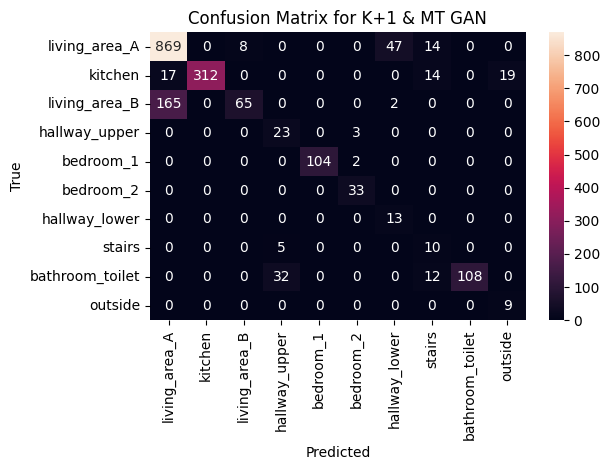

In [10]:
all_results = []

for exp_name, split_ratio in labeled_experiments:

  labeled_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_labeled_{exp_name}.npz"
  unlabeled_train_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_unlabeled_{exp_name}_train.npz"
  unlabeled_eval_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_full_validation_set.npz"

  # Prepare loaders
  loader_labeled, loader_unlabeled_train, loader_unlabeled_val, criterion_real_full, criterion_real_10, criterion_fake = prepare_training_loaders(labeled_npz, unlabeled_train_npz, unlabeled_eval_npz)

  for FEATURES_DISC in feature_disc_options:
      for LEARNING_RATE in learning_rate_options:
        for RAMP_UP in ramp_up_options:
          for BASE_CONSISTENCY_WEIGHT in base_consistency_options:
            for CONFIDENCE_THRESHOLD in confidence_threshold_options:
              for TEMP_SHARPEN in temp_sharpen_options:
                # if exp_name == "experiment2" and FEATURES_DISC == 128:
                #   continue
                # if exp_name == "experiment3" and FEATURES_DISC == 64:
                #   continue
                # if exp_name == "experiment4" and FEATURES_DISC == 64:
                #   continue
                print(f"FEATURES_DISC={FEATURES_DISC}, LEARNING_RATE={LEARNING_RATE}, RAMPUP={RAMP_UP}, BCON_WEIGHT={BASE_CONSISTENCY_WEIGHT}, CON_THRESHOLD={CONFIDENCE_THRESHOLD}, TEACHER_UPDATE_FREQ={TEACHER_UPDATE_FREQ}, TEMP_SHARP={TEMP_SHARPEN}")
                model_name = f"MTGAN_{exp_name}_FDISC{FEATURES_DISC}_LR{LEARNING_RATE}_RU{RAMP_UP}_CW{BASE_CONSISTENCY_WEIGHT}_CT{CONFIDENCE_THRESHOLD}_TS{TEMP_SHARPEN}"

                # Load pretrained models
                gen, disc, opt_gen, opt_disc, scaler, scheduler_gen, scheduler_disc = load_pretrained_models(checkpoint_path)

                # Create Teacher model
                teacher_disc = copy.deepcopy(disc).to(DEVICE)
                for p in teacher_disc.parameters():
                  p.requires_grad = False

                # Train Mean Teacher
                train_mean_teacher_k_plus_1(
                  gen, disc, teacher_disc,
                  opt_gen, opt_disc,
                  scaler, scheduler_disc,
                  loader_labeled, loader_unlabeled_train,
                  criterion_real_full, criterion_fake,
                  split_ratio,
                  model_name,
                  save_training_logs_csv,
                  ramp_up_epochs=RAMP_UP,
                  base_consistency_weight=BASE_CONSISTENCY_WEIGHT,
                  confidence_threshold=CONFIDENCE_THRESHOLD,
                  teacher_update_freq=TEACHER_UPDATE_FREQ,
                  temp_sharpen=TEMP_SHARPEN
                )

                # Evaluate on validation set
                acc, macro_f1 = evaluate_mt(
                  teacher_disc,
                  loader_unlabeled_val,
                  house_d_label_to_id,
                  model_name
                )

                all_results.append({
                  "experiment": exp_name,
                  "split_ratio": split_ratio,
                  "features_disc": FEATURES_DISC,
                  "learning_rate": LEARNING_RATE,
                  "ramp_up": RAMP_UP,
                  "base_weight": BASE_CONSISTENCY_WEIGHT,
                  "conf_threshold": CONFIDENCE_THRESHOLD,
                  "teacher_update_freq": TEACHER_UPDATE_FREQ,
                  "temp_sharpen": TEMP_SHARPEN,
                  "accuracy": acc,
                  "macro_f1": macro_f1
                })

# Save all results
results_df = pd.DataFrame(all_results)
results_df.to_csv(save_results_csv, index=False)

In [11]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(save_results_csv, index=False)